| Dataset     | Vertices | Edges | BMSSP V1 | Dijkstra | BMSSP-V2 (Optimized) | Dijkstra (Optimized) |
| :---------- | -------: | ----: | -------: | -------: | -------------------: | -------------------: |
| Stanford    |     281K |  2.3M |  1.0779s |  0.3447s |          **0.2141s** |              0.3171s |
| Google      |     916K |  5.1M |  2.6174s |  1.1571s |          **0.6392s** |              1.1297s |
| Pokec       |     1.6M | 30.6M | 24.1432s |  7.0684s |          **4.1297s** |              6.4779s |
| California  |     1.9M |  2.7M |  7.3192s |  2.2727s |          **1.9153s** |              2.1733s |
| LiveJournal |     4.8M | 69.0M | 62.0967s | 18.1283s |          **9.5515s** |              16.4488 |

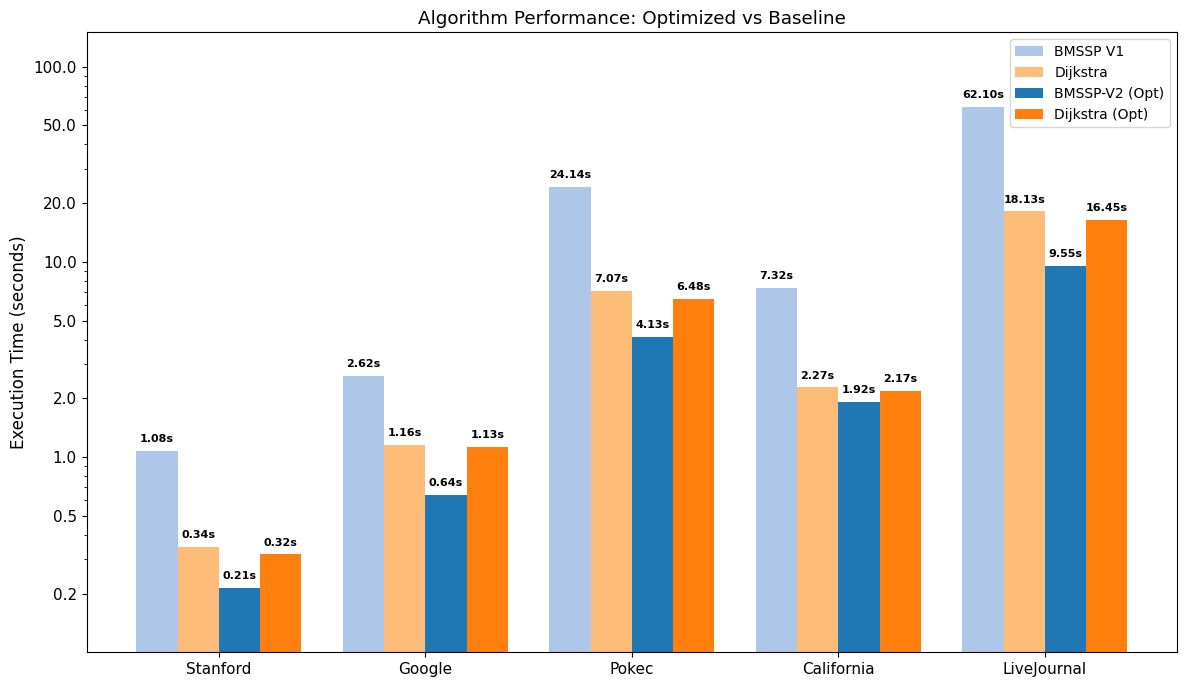

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pandas as pd
import numpy as np

data = {
    'Dataset': ['Stanford', 'Google', 'Pokec', 'California', 'LiveJournal'],
    'BMSSP V1': [1.0779, 2.6174, 24.1432, 7.3192, 62.0967],
    'Dijkstra': [0.3447, 1.1571, 7.0684, 2.2727, 18.1283],
    'BMSSP-V2 (Optimized)': [0.2141, 0.6392, 4.1297, 1.9153, 9.5515],
    'Dijkstra (Optimized)': [0.3171, 1.1297, 6.4779, 2.1733, 16.4488]
}

df = pd.DataFrame(data)

x = np.arange(len(df['Dataset']))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - 1.5*width, df['BMSSP V1'], width, label='BMSSP V1', color='#aec7e8')
rects2 = ax.bar(x - 0.5*width, df['Dijkstra'], width, label='Dijkstra', color='#ffbb78')
rects3 = ax.bar(x + 0.5*width, df['BMSSP-V2 (Optimized)'], width, label='BMSSP-V2 (Opt)', color='#1f77b4')
rects4 = ax.bar(x + 1.5*width, df['Dijkstra (Optimized)'], width, label='Dijkstra (Opt)', color='#ff7f0e')

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0.2, 0.5, 1, 2, 5, 10, 20, 50, 100])

# 2. ADD DATA LABELS
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}s',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

for r in [rects1, rects2, rects3, rects4]:
    autolabel(r)

ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Algorithm Performance: Optimized vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(df['Dataset'])
ax.legend()
plt.ylim(0.1, 150)
plt.tight_layout()
plt.show()
